# Examen final
### Análisis de dataset de imágenes MRI cerebrales

Este proyecto analizará 40.000 imágenes IRM cerebrales para poder entrenar un modelo de regresión logistica* el cual predicirá, dados los datos extraídos de una imagen, si un paciente tiene alzheimers o no.

Para esto, se necesitará:
- Obtener el dataset desde Kaggle
- Transformar datos de imágenes a datos en csv, obteniendo toda la información relevante
- Agrupar los csv en un DataFrame
- Entrenar y probar un modelo de regresión lineal para predecir si un paciente tiene alzheimers o no, y que tan severo es.

### Importación

https://www.kaggle.com/datasets/uraninjo/augmented-alzheimer-mri-dataset

In [8]:
import kagglehub
# descargar a la misma carpeta:
kagglehub.dataset_download("uraninjo/augmented-alzheimer-mri-dataset")

base_path = "/kaggle/input/augmented-alzheimer-mri-dataset"



Using Colab cache for faster access to the 'augmented-alzheimer-mri-dataset' dataset.


'/kaggle/input/augmented-alzheimer-mri-dataset'

El unico "problema" de este dataset es que los MRIs de pacientes con Alzheimers pueden ser bastante dificiles de encontrar.

A los pacientes con esta enfermedad no les agrada estar en una maquina ruidosa por varias horas, y el diagnostico usualmente es relativamente obvio.

In [4]:
!pip install stats
!pip install scikit-image

In [5]:
import pandas as pd
import stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Tenemos los datos, pero no podemos usarlos todavia dado que nuestras herramientas no incluyen librerías como tensorflow que puedan trabajar con imágenes.

Primero, debemos definir que parte de cada imagen es que. Debemos definir que parte es:
- Fluido cerebroespinal
- Materia gris
- Materia blanca

En cada imagen.

Para esto, usaremos Pillow. Sin embargo, debemos también entender que no existen rangos específicos universales para la escala de grises que usaremos para extraer las características necesarias de las imágenes.

Entonces primero que todo, debemos nosotros mismos investigar que rango correspondería a este dataset.

Para analizar las imágenes, también necesitamos OpenCV (cv2) con la cual podemos leer imagenes con escala gris.

Para sacar los limites, analizaremos los minimos locales de cada imagen en las carpetas para encontrar limites de FCE y MG, y de MG y MB. Luego, se van a promediar estos para encontrar una buena aproximacion para los limites necesarios.

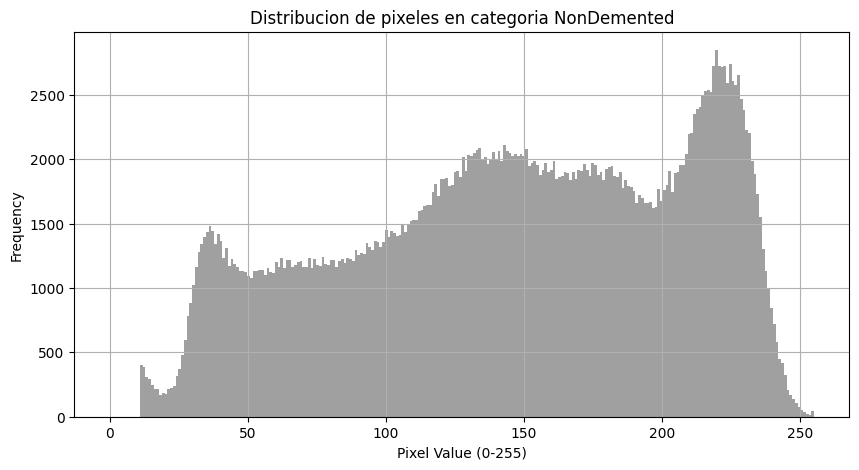

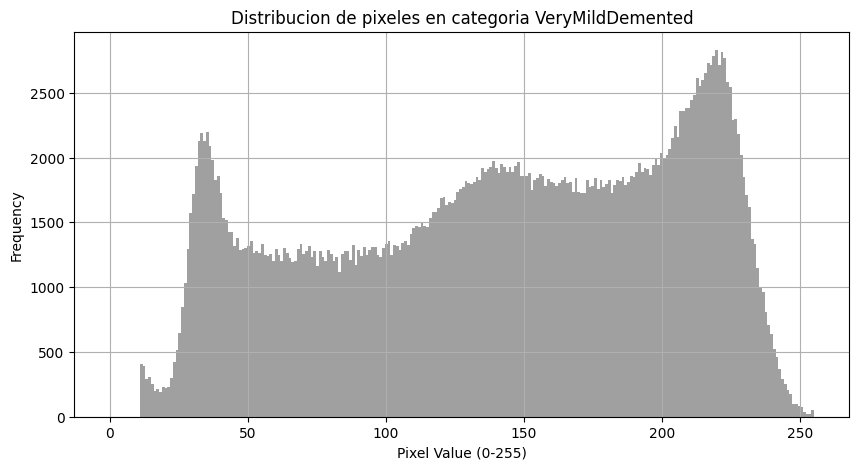

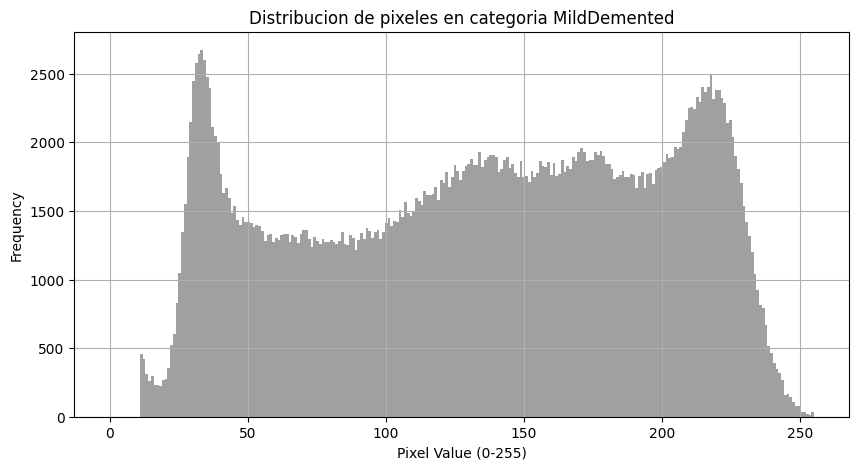

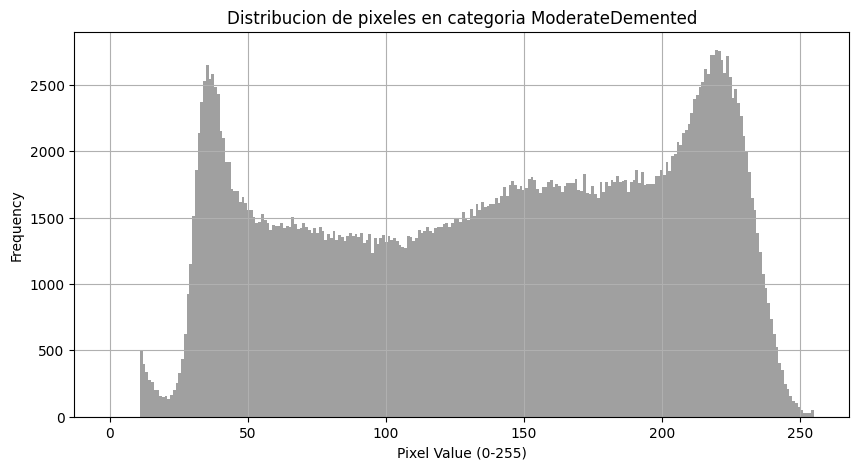

In [ ]:
import os
from PIL import Image
import cv2

listaClases = ['NonDemented', 'VeryMildDemented', 'MildDemented', 'ModerateDemented']

listaPixeles = []
limites = []

for i in listaClases:
    DATASET_DIR = f"{base_path}/OriginalDataset/{i}"
    sample_files = os.listdir(DATASET_DIR)[:1000] # usamos 1000 imagenes como muestra.. limites de colab

    all_pixels = []

    for file in sample_files:
        if file.endswith('.jpg'):
            img = cv2.imread(os.path.join(DATASET_DIR, file), cv2.IMREAD_GRAYSCALE) # leer imagen en grayscale con cv2
            pixels = img[img > 10].flatten()
            all_pixels.extend(pixels)
            counts, _ = np.histogram(pixels, bins=256, range=(0, 255))
            window_size = 11
            smoothed = np.convolve(counts, np.ones(window_size)/window_size, mode='same')
            csf_gm_valley = 40 + np.argmin(smoothed[40:80])
            gm_wm_valley = 160 + np.argmin(smoothed[160:200])
            limites.append((csf_gm_valley, gm_wm_valley))
    # plot
    plt.figure(figsize=(10, 5))
    plt.hist(all_pixels, bins=256, range=(0, 255), color='gray', alpha=0.75)
    plt.title(f"Distribucion de pixeles en categoria {i}")
    plt.xlabel("Pixel Value (0-255)")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

In [11]:
print(limites)
meanValleys = np.mean(limites, axis=0)

print(meanValleys)

[(np.int64(64), np.int64(196)), (np.int64(74), np.int64(170)), (np.int64(78), np.int64(181)), (np.int64(52), np.int64(160)), (np.int64(74), np.int64(194)), (np.int64(79), np.int64(161)), (np.int64(40), np.int64(175)), (np.int64(79), np.int64(178)), (np.int64(40), np.int64(197)), (np.int64(76), np.int64(188)), (np.int64(79), np.int64(195)), (np.int64(40), np.int64(199)), (np.int64(42), np.int64(188)), (np.int64(50), np.int64(174)), (np.int64(50), np.int64(180)), (np.int64(42), np.int64(182)), (np.int64(46), np.int64(190)), (np.int64(54), np.int64(186)), (np.int64(46), np.int64(194)), (np.int64(45), np.int64(199)), (np.int64(79), np.int64(199)), (np.int64(61), np.int64(171)), (np.int64(70), np.int64(176)), (np.int64(71), np.int64(197)), (np.int64(43), np.int64(172)), (np.int64(52), np.int64(179)), (np.int64(78), np.int64(194)), (np.int64(42), np.int64(188)), (np.int64(62), np.int64(177)), (np.int64(58), np.int64(187)), (np.int64(61), np.int64(190)), (np.int64(76), np.int64(163)), (np.int

De esto, podemos tener que los limites estan entre 0, 58, 180, 255. (Con muestra de 2000 datos max)

Por lo tanto, cuando hablamos de valores de escala gris:

- Fluido cerebroespinal: 0-58
- Materia gris: 59-180
- Materia blanca: 181-255

## Investigación

Ahora, con los datos que tenemos, queremos ver como podemos usarlos para predecir Alzheimers en una persona.

Que sabemos del Alzheimers?

- El cerebro se encoge en general.
- Provoca disminución de materia gris y materia blanca.
- Al disminuir la materia gris y la materia blanca, el fluido cerebroespinal rellena los vacíos dejados por la ausencia de ambas materias.

No podemos simplemente decir que si una imagen tiene menos pixeles, entonces es mas posible que la persona tenga Alzheimers, ya que el cerebro de cada uno es muy distinto al del otro. Cada uno tiene un cráneo o cerebro de tamaño diferente, y eso no es indicación de Alzheimers o de mayor/menor capacidad cognitiva.

Lo que si podemos usar es el BV/CSF Index.

$$BV/CSF = \frac{MG\ Total + MB\ Total}{FCE\ Total}$$

Con:

- MG = Materia Gris
- MB = Materia Blanca
- FCE = Fluido Cerebroespinal




Este índice es usado en neuroimagenología para medir el volumen del cerebro, y es una variable que podemos usar para nuestra regresión logistica.

Para esto, debemos calcular el índice para cada una de nuestras imágenes.

In [13]:
# Iterar sobre cada clase
imagePixels = [] # Inicializa lista de datos que se convertirá en diccionario

for i in listaClases:
    DATASET_DIR = f"{base_path}/OriginalDataset/{i}"
    sample_files = os.listdir(DATASET_DIR)



    for file in sample_files:
        if file.endswith('.jpg'):
            img = cv2.imread(os.path.join(DATASET_DIR, file), cv2.IMREAD_GRAYSCALE) # leer imagen en grayscale con cv2
            pixels = img[img > 10].flatten()
            all_pixels.extend(pixels)
            counts, _ = np.histogram(pixels, bins=256, range=(0, 255))
            window_size = 11
            smoothed = np.convolve(counts, np.ones(window_size)/window_size, mode='same')
            FCE = int(smoothed[0:57].sum())
            MG = int(smoothed[58:179].sum())
            MB = int(smoothed[180:255].sum())
            if FCE > 100: # Saca outliers
                BVCSFIndex = ((MG + MB)/FCE)

            else:
                BVCSFIndex = np.NaN
            # Nuestros rangos son:
            # Fluido Cerebroespinal: 0-58
            # Materia gris: 59-180
            # Materia blanca: 181-255
            imagePixels.append({
                "IDImagen": file,
                "Fluido Cerebroespinal": FCE, # 0 a 59
                "Materia Gris": MG, # 60 a 180
                "Materia Blanca": MB, # 181 a 255
                "BV/CSF Index": BVCSFIndex,
                "Clase": i
            })


Ahora, tenemos un diccionario con datos correspondientes a cada imagen.

In [14]:
df = pd.DataFrame(imagePixels)
df = df.dropna()

Aca mismo es donde decidi cambiar el proyecto a uno de regresion logística; originalmente, usaba regresión lineal.

In [15]:
ModerateDemented = df.loc[df['Clase'] == 'ModerateDemented']
MildDemented = df.loc[df['Clase'] == 'MildDemented']
VeryMildDemented = df.loc[df['Clase'] == 'VeryMildDemented']
NonDemented = df.loc[df['Clase'] == 'NonDemented']
display(ModerateDemented.describe())
display(MildDemented.describe())
display(VeryMildDemented.describe())
display(NonDemented.describe())

,Fluido Cerebroespinal,Materia Gris,Materia Blanca,BV/CSF Index
count,64.000000,64.000000,64.000000,64.000000
mean,2933.250000,9105.484375,6189.609375,5.756711
std,847.943039,1131.716115,1269.241488,1.931808
min,1630.000000,7007.000000,3351.000000,3.200686
25%,2130.000000,8234.750000,5375.250000,3.935383
50%,2888.000000,9318.500000,6048.500000,5.507654
75%,3725.000000,9902.750000,7157.250000,7.504086
max,4370.000000,11458.000000,8130.000000,9.411656


,Fluido Cerebroespinal,Materia Gris,Materia Blanca,BV/CSF Index
count,896.000000,896.000000,896.000000,896.000000
mean,3132.033482,9636.755580,5462.304688,5.220132
std,767.987431,1590.358188,1590.426269,1.754110
min,969.000000,6580.000000,5.000000,2.358932
25%,2568.750000,8574.750000,5033.500000,3.994521
50%,3115.000000,9633.500000,5867.000000,4.877246
75%,3625.250000,10409.000000,6375.000000,6.144902
max,5430.000000,15364.000000,8911.000000,16.581011


,Fluido Cerebroespinal,Materia Gris,Materia Blanca,BV/CSF Index
count,2240.000000,2240.000000,2240.000000,2240.000000
mean,2613.468304,9670.998661,5950.555804,7.032656
std,964.543042,1704.026199,1844.056104,3.256640
min,644.000000,6417.000000,1.000000,1.406564
25%,1920.000000,8428.500000,5540.250000,4.803542
50%,2514.500000,9566.500000,6330.500000,6.299868
75%,3133.250000,10441.500000,7063.750000,8.436125
max,7374.000000,16480.000000,9134.000000,25.366460


,Fluido Cerebroespinal,Materia Gris,Materia Blanca,BV/CSF Index
count,3200.000000,3200.000000,3200.000000,3200.000000
mean,1929.078438,9626.724375,6692.818750,10.787909
std,896.718326,1688.570108,1660.240392,5.718530
min,399.000000,6516.000000,1.000000,2.654660
25%,1215.750000,8362.500000,5931.750000,6.215632
50%,1733.500000,9610.000000,6968.000000,9.544354
75%,2517.000000,10424.500000,7788.000000,14.000637
max,4914.000000,17140.000000,10091.000000,41.711779


Examinemos mejor estos datos:

/tmp/ipykernel_5555/3578467523.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_csf, patch_artist=True, labels=order,


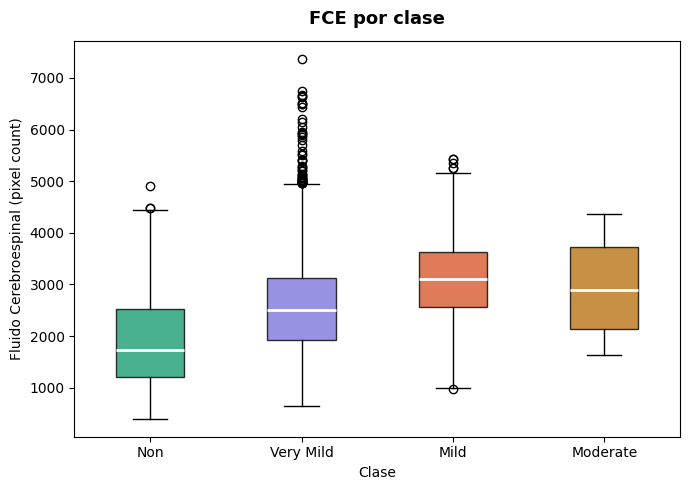

/tmp/ipykernel_5555/3578467523.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_bvcsf, patch_artist=True, labels=order,


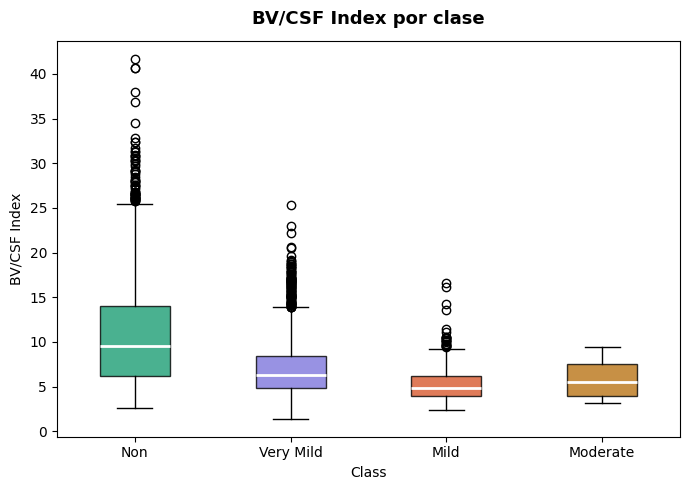

In [78]:
df_plot = pd.concat([
    ModerateDemented,
    MildDemented,
    VeryMildDemented,
    NonDemented
]).copy()

short_names = {
    'NonDemented':       'Non',
    'VeryMildDemented':  'Very Mild',
    'MildDemented':      'Mild',
    'ModerateDemented':  'Moderate'
}
df_plot['Clase_short'] = df_plot['Clase'].map(short_names)
order = ['Non', 'Very Mild', 'Mild', 'Moderate']
colors = ['#1D9E75', '#7F77DD', '#D85A30', '#BA7517']

# --- Plot 1: CSF levels ---
fig, ax = plt.subplots(figsize=(7, 5))
data_csf = [df_plot[df_plot['Clase_short'] == cl]['Fluido Cerebroespinal'].dropna() for cl in order]
bp = ax.boxplot(data_csf, patch_artist=True, labels=order,
                medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.set_title('FCE por clase', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Fluido Cerebroespinal (pixel count)')
ax.set_xlabel('Clase')
plt.tight_layout()
plt.show()

# --- Plot 2: BV/CSF Index ---
fig, ax = plt.subplots(figsize=(7, 5))
data_bvcsf = [df_plot[df_plot['Clase_short'] == cl]['BV/CSF Index'].dropna() for cl in order]
bp = ax.boxplot(data_bvcsf, patch_artist=True, labels=order,
                medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.set_title('BV/CSF Index por clase', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('BV/CSF Index')
ax.set_xlabel('Class')
plt.tight_layout()
plt.show()

### Modelo regresion logistica

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

label_map = {
    "NonDemented": 0,
    "VeryMildDemented": 1,
    "MildDemented": 2,
    "ModerateDemented": 3
}
df["Target_Y"] = df["Clase"].map(label_map)

X = df[["Fluido Cerebroespinal", "Materia Gris", "Materia Blanca", "BV/CSF Index"]]
y = df["Target_Y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    class_weight='balanced',
    max_iter=1000
)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [61]:
print("MATRIZ DE CONFUSIÓN")
print(confusion_matrix(y_test, y_pred))

print("\nREPORTE DE CLASIFICACIÓN")
target_names = ["Non Demented", "Very Mild", "Mild", "Moderate"]
print(classification_report(y_test, y_pred, target_names=target_names))

MATRIZ DE CONFUSIÓN
[[188 164  26  22]
 [ 42 248  55  55]
 [  1  66  68  44]
 [  0   5   2   6]]

REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

Non Demented       0.81      0.47      0.60       400
   Very Mild       0.51      0.62      0.56       400
        Mild       0.45      0.38      0.41       179
    Moderate       0.05      0.46      0.09        13

    accuracy                           0.51       992
   macro avg       0.46      0.48      0.41       992
weighted avg       0.62      0.51      0.54       992



Los resultados no son tan buenos, pero podemos intentar mejorarlos. Medidas a tomar:
- Entrenar en los datos aumentados, probar en datos originales
- Agregar mas variables mediante otro analisis

## Proceso de mejora

- Se aplico el protocolo de entrenar en datos aumentados y probar en originales.
- Se agregaron las siguientes variables, mediante funciones de skimage:
  - GLCM (Gray Level Co-Ocurrence Matrix):
    - GLCM en sí mide el valor de los pixeles vecinos de cada pixel de la imagen. Esta tiene 4 medidas:
    - Contraste: Mide que tan distintos son los pixeles vecinos en promedio.
    - Homogenidad: Mide que tan *similares* son los pixeles vecinos en promedio.
    - Energía: Mide que tan repetitivas son las regiones de la imagen: un valor alto de energía significa que una región contiene un patrón que se repite mucho.
    - Correlación: Mide que tan predecible es el valor de un pixel dado su vecino.
  - LBP (Local Binary Pattern)
    - Examina los pixeles alrededor de cada pixel, entregando un 1 si el pixel tiene un valor de escala gris mas alto y un 0 en otro caso. Esto nos ayuda a ver la textura general de la imagen.



In [51]:
import os
import cv2
import numpy as np
import pandas as pd
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern

listaClases = ['NonDemented', 'VeryMildDemented', 'MildDemented', 'ModerateDemented']

def extractFeatures(base_path, max_images):
    extracted_data = []
    for cl in listaClases:
        dataset_dir = f"{base_path}/{cl}"
        if not os.path.exists(dataset_dir):
            continue

        sample_files = os.listdir(dataset_dir)[:max_images]

        for file in sample_files:
            if not file.endswith('.jpg'):
                continue

            path = os.path.join(dataset_dir, file)
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue

            img_resized = cv2.resize(img, (128, 128))

            # --- Histogram features ---
            pixels = img[img > 10].flatten()
            counts, _ = np.histogram(pixels, bins=256, range=(0, 255))
            smoothed = np.convolve(counts, np.ones(11) / 11, mode='same')
            fce = int(smoothed[0:60].sum())
            mg  = int(smoothed[60:181].sum())
            mb  = int(smoothed[181:255].sum())
            bv_csf = (mg + mb) / fce if fce > 100 else np.nan

            # GLCM
            glcm        = graycomatrix(img_resized, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
            contrast    = graycoprops(glcm, 'contrast')[0, 0]
            homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
            energy      = graycoprops(glcm, 'energy')[0, 0]
            correlation = graycoprops(glcm, 'correlation')[0, 0]

            # LBP
            lbp = local_binary_pattern(img_resized, P=8, R=1, method='uniform')
            lbp_hist, _ = np.histogram(lbp, bins=10, range=(0, 10), density=True)

            extracted_data.append({
                "IDImagen":               file,
                "Fluido Cerebroespinal":  fce,
                "Materia Gris":           mg,
                "Materia Blanca":         mb,
                "BV/CSF Index":           bv_csf,
                "Contrast":               contrast,
                "Homogeneity":            homogeneity,
                "Energy":                 energy,
                "Correlation":            correlation,
                **{f"LBP_{i}": lbp_hist[i] for i in range(10)},
                "Clase":                  cl,
            })

    return pd.DataFrame(extracted_data)
# Generar ambas DF

df_original_raw = extractFeatures(
    os.path.join(base_path, "OriginalDataset"),
    max_images=2000
)
df_augmented_raw = extractFeatures(
    os.path.join(base_path, "AugmentedAlzheimerDataset"),
    max_images=3000
)



In [52]:
# Eliminacion de valores nulos de BV/CSF Index
df_original = df_original_raw.dropna(subset=["BV/CSF Index"])
df_augmented = df_augmented_raw.dropna(subset=["BV/CSF Index"])

In [53]:
# aplicar map a clases; convertir clases en string a numeros
label_map = {"NonDemented": 0, "VeryMildDemented": 1, "MildDemented": 2, "ModerateDemented": 3}
df_original["Target_Y"] = df_original["Clase"].map(label_map)
df_augmented["Target_Y"] = df_augmented["Clase"].map(label_map)

df_test = df_original.groupby("Target_Y", group_keys=False).apply(
    lambda x: x.sample(frac=0.2, random_state=42)
)

test_filenames = set(df_test["IDImagen"].tolist())

df_train = df_augmented[~df_augmented["IDImagen"].isin(test_filenames)]

/tmp/ipykernel_5555/696173432.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_augmented["Target_Y"] = df_augmented["Clase"].map(label_map)
/tmp/ipykernel_5555/696173432.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_test = df_original.groupby("Target_Y", group_keys=False).apply(


In [73]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

feature_cols = [
    "Fluido Cerebroespinal",
    "Materia Gris",
    "Materia Blanca",
    "BV/CSF Index",
    "Contrast",
    "Homogeneity",
    "Energy",
    "Correlation",
    *[f"LBP_{i}" for i in range(10)]
]

X_train = df_train[feature_cols]
y_train = df_train["Target_Y"]

X_test = df_test[feature_cols]
y_test = df_test["Target_Y"]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    class_weight='balanced',
    max_iter=2000
)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("MATRIZ DE CONFUSIÓN")
print(confusion_matrix(y_test, y_pred))

print("\nREPORTE DE CLASIFICACIÓN")
print(classification_report(y_test, y_pred, target_names=listaClases))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


MATRIZ DE CONFUSIÓN
[[188 164  26  22]
 [ 42 248  55  55]
 [  1  66  68  44]
 [  0   5   2   6]]

REPORTE DE CLASIFICACIÓN
                  precision    recall  f1-score   support

     NonDemented       0.81      0.47      0.60       400
VeryMildDemented       0.51      0.62      0.56       400
    MildDemented       0.45      0.38      0.41       179
ModerateDemented       0.05      0.46      0.09        13

        accuracy                           0.51       992
       macro avg       0.46      0.48      0.41       992
    weighted avg       0.62      0.51      0.54       992



Relativamente mejor! Pero no es exactamente perfecto, y no hay mucho que podamos hacer para mejorarlo.

Que es lo que sacamos de esto?

### Visualizaciones

In [55]:
!pip install seaborn

In [74]:
import seaborn as sns
from sklearn.preprocessing import label_binarize


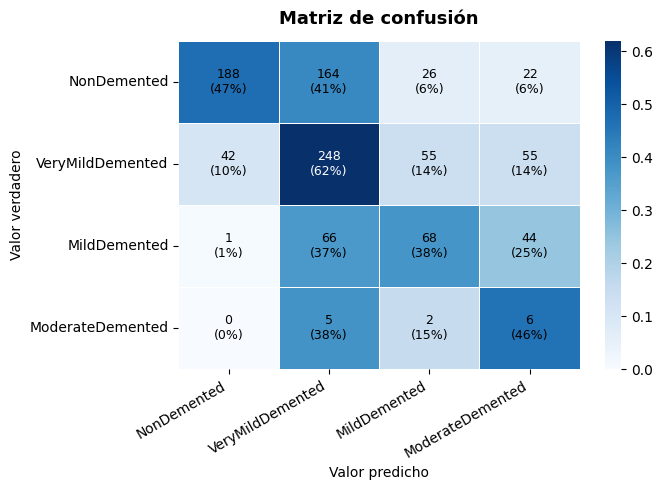

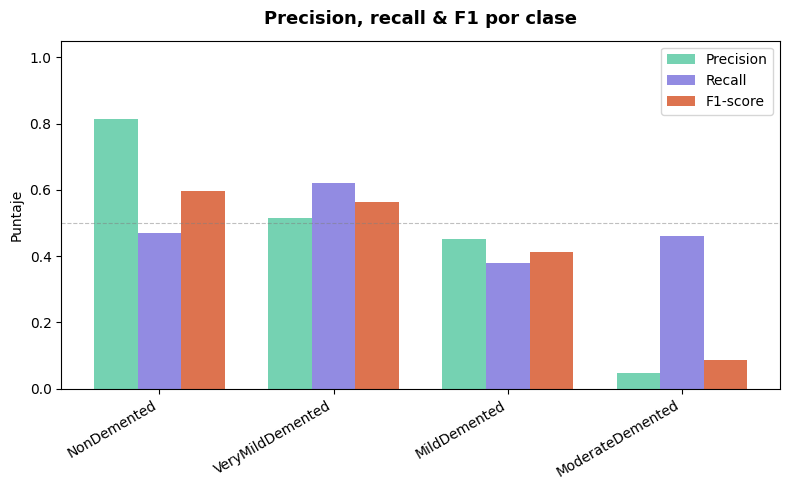

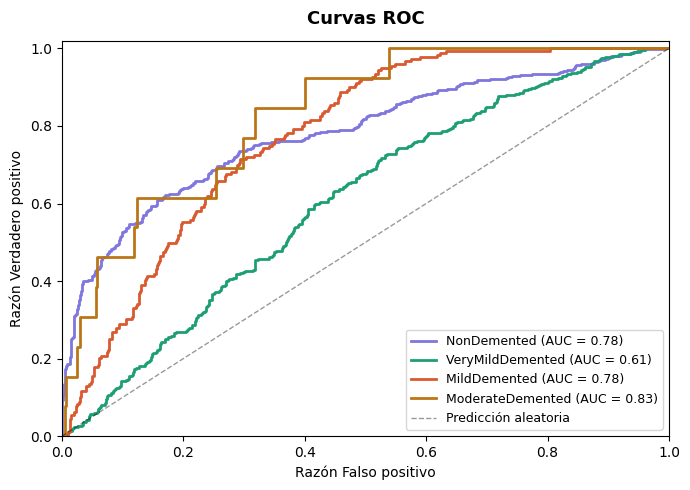

In [77]:
# matriz de confusión
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm_norm, annot=False, cmap='Blues',
            xticklabels=listaClases, yticklabels=listaClases, ax=ax,
            linewidths=0.5, linecolor='white')
for i in range(len(listaClases)):
    for j in range(len(listaClases)):
        ax.text(j + 0.5, i + 0.5,
                f'{cm[i,j]}\n({cm_norm[i,j]:.0%})',
                ha='center', va='center', fontsize=9,
                color='white' if cm_norm[i,j] > 0.5 else 'black')
ax.set_title('Matriz de confusión', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Valor verdadero')
ax.set_xlabel('Valor predicho')
ax.set_xticklabels(listaClases, rotation=30, ha='right')
plt.tight_layout()
plt.show()

# visualización de precisión/recall/f1

report = classification_report(y_test, y_pred, target_names=listaClases, output_dict=True)
metrics = ['precision', 'recall', 'f1-score']
x = np.arange(len(listaClases))
width = 0.25
colors = ['#5DCAA5', '#7F77DD', '#D85A30']

fig, ax = plt.subplots(figsize=(8, 5))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    vals = [report[cl][metric] for cl in listaClases]
    ax.bar(x + i * width, vals, width, label=metric.capitalize(), color=color, alpha=0.85)
ax.set_xticks(x + width)
ax.set_xticklabels(listaClases, rotation=30, ha='right')
ax.set_ylim(0, 1.05)
ax.set_title('Precision, recall & F1 por clase', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Puntaje')
ax.legend()
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.show()

# Curvas ROC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])
y_score = model.predict_proba(X_test_scaled)
roc_colors = ['#7F77DD', '#1D9E75', '#D85A30', '#BA7517']

fig, ax = plt.subplots(figsize=(7, 5))
for i, (cls, color) in enumerate(zip(listaClases, roc_colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{cls} (AUC = {roc_auc:.2f})') # auc = area under curve, area bajo curva
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4, label='Predicción aleatoria')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('Razón Falso positivo')
ax.set_ylabel('Razón Verdadero positivo (Recall)')
ax.set_title('Curvas ROC', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()



*Mayor AUC es mejor.*

## Resultados

En este proyecto, se realizó un modelo de regresión logística para poder intentar predecir la severidad de Alzheimers en una persona determinada, dada una imagen de resonancia magnética.

Esta es una tarea muy dificil, ya que los métodos de entrenamiento de modelos que usan imágenes son bastante diferentes a los métodos de entrenamiento de modelos que usan CSV o DataFrame.

Al analizar los datos, se encontró una relación entre nivel de demencia y aumento en volumen de pixeles correspondientes al fluido cerebroespinal, pero disminuición en el índice BV/CSF. Luego de esto, se entrenaron modelos para predecir clase de Alzheimers tomando en cuenta las variables relevantes.

Sin embargo, originalmente y mas aún luego de algunas modificaciones, los resultados mejoraron y el modelo pudo predecir con un grado de certeza relativamente significante si un paciente tiene Alzheimers o no, y específicamente, que nivel de Alzheimers tiene.